In [13]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [14]:
df_plot = pd.read_csv('motifs_count_by_class.csv')

In [16]:
df_plot.head()


,nlr_class,motifs,count
0,TNLR,motif_13,395
1,TNLR,motif_15,393
2,TNLR,motif_18,384
3,TNLR,motif_5,304
4,TNLR,motif_1,293


In [21]:

# Get totals per class
cc_total = 85
tir_total = 410

# Pivot 
df_pivot = df_plot.pivot_table(index='motifs', columns='nlr_class', values='count', fill_value=0)
df_pivot.head()


nlr_class,CNLR,NLR,TNLR
motifs,,,
motif_1,80.0,115.0,293.0
motif_10,62.0,98.0,240.0
motif_11,66.0,90.0,230.0
motif_12,71.0,88.0,174.0
motif_13,0.0,0.0,395.0


In [25]:
print(df_pivot.index)


Index(['motif_1', 'motif_10', 'motif_11', 'motif_12', 'motif_13', 'motif_14',
       'motif_15', 'motif_16', 'motif_17', 'motif_18', 'motif_19', 'motif_2',
       'motif_20', 'motif_3', 'motif_4', 'motif_5', 'motif_6', 'motif_7',
       'motif_8', 'motif_9'],
      dtype='str', name='motifs')


In [28]:
df_pivot['CC-NLR%'] = df_pivot['CNLR'] / cc_total * 100
df_pivot['TIR-NLR%'] = df_pivot['TNLR'] / tir_total * 100
df_pivot['motif_num'] = df_pivot.index.str.extract(r'motif_(\d+)', expand=False).astype(int)
df_pivot = df_pivot.sort_values('motif_num')
df_pivot

nlr_class,CNLR,NLR,TNLR,CC-NLR%,TIR-NLR%,motif_num
motifs,,,,,,
motif_1,80.0,115.0,293.0,94.117647,71.463415,1
motif_2,75.0,60.0,0.0,88.235294,0.000000,2
motif_3,75.0,109.0,265.0,88.235294,64.634146,3
motif_4,65.0,115.0,290.0,76.470588,70.731707,4
motif_5,63.0,114.0,304.0,74.117647,74.146341,5
motif_6,81.0,58.0,1.0,95.294118,0.243902,6
motif_7,75.0,87.0,206.0,88.235294,50.243902,7
motif_8,54.0,20.0,5.0,63.529412,1.219512,8
motif_9,72.0,87.0,205.0,84.705882,50.000000,9


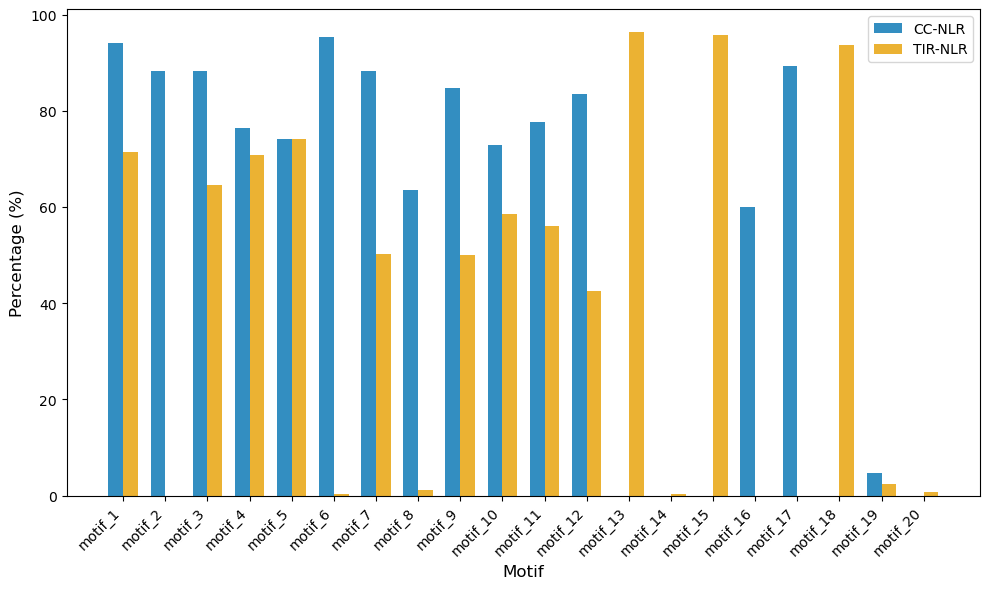

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_pivot))
width = 0.35

ax.bar(x - width/2, df_pivot['CC-NLR%'], width, label='CC-NLR', color='#0072B2', alpha=0.8)
ax.bar(x + width/2, df_pivot['TIR-NLR%'], width, label='TIR-NLR', color='#E69F00', alpha=0.8)

ax.set_xlabel('Motif', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_pivot.index, rotation=45, ha='right')  # horizontal labels
ax.legend()
ax.grid(False)  # remove grid

plt.tight_layout()
plt.show()
